# Challenge 1 - Tic Tac Toe

In this lab you will perform deep learning analysis on a dataset of playing [Tic Tac Toe](https://en.wikipedia.org/wiki/Tic-tac-toe).

There are 9 grids in Tic Tac Toe that are coded as the following picture shows:

![Tic Tac Toe Grids](tttboard.jpg)

In the first 9 columns of the dataset you can find which marks (`x` or `o`) exist in the grids. If there is no mark in a certain grid, it is labeled as `b`. The last column is `class` which tells you whether Player X (who always moves first in Tic Tac Toe) wins in this configuration. Note that when `class` has the value `False`, it means either Player O wins the game or it ends up as a draw.

Follow the steps suggested below to conduct a neural network analysis using Tensorflow and Keras. You will build a deep learning model to predict whether Player X wins the game or not.

## Step 1: Data Engineering

This dataset is almost in the ready-to-use state so you do not need to worry about missing values and so on. Still, some simple data engineering is needed.

1. Read `tic-tac-toe.csv` into a dataframe.
1. Inspect the dataset. Determine if the dataset is reliable by eyeballing the data.
1. Convert the categorical values to numeric in all columns.
1. Separate the inputs and output.
1. Normalize the input data.

In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

# Read data
df = pd.read_csv("tic-tac-toe.csv")

# Inspect
print(df.shape)
print(df.head())
print(df.dtypes)
print(df["class"].value_counts())

# Convert categorical to numeric
# x = 1, o = -1, b = 0 (intuitive encoding for a game state)
df = df.replace({"x": 1, "o": -1, "b": 0})

# Convert target: True = 1, False = 0
df["class"] = df["class"].astype(int)

# Separate inputs and output
X = df.drop(columns="class").values
y = df["class"].values

# Normalize input data
scaler = StandardScaler()
X = scaler.fit_transform(X)

print(f"\nX shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"Class balance:\n {pd.Series(y).value_counts()}")

(958, 10)
  TL TM TR ML MM MR BL BM BR  class
0  x  x  x  x  o  o  x  o  o   True
1  x  x  x  x  o  o  o  x  o   True
2  x  x  x  x  o  o  o  o  x   True
3  x  x  x  x  o  o  o  b  b   True
4  x  x  x  x  o  o  b  o  b   True
TL       object
TM       object
TR       object
ML       object
MM       object
MR       object
BL       object
BM       object
BR       object
class      bool
dtype: object
class
True     626
False    332
Name: count, dtype: int64

X shape: (958, 9)
y shape: (958,)
Class balance:
 1    626
0    332
Name: count, dtype: int64


C:\Users\ferna\AppData\Local\Temp\ipykernel_15676\971145652.py:16: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.replace({"x": 1, "o": -1, "b": 0})


## Step 2: Build Neural Network

To build the neural network, you can refer to your own codes you wrote while following the [Deep Learning with Python, TensorFlow, and Keras tutorial](https://www.youtube.com/watch?v=wQ8BIBpya2k) in the lesson. It's pretty similar to what you will be doing in this lab.

1. Split the training and test data.
1. Create a `Sequential` model.
1. Add several layers to your model. Make sure you use ReLU as the activation function for the middle layers. Use Softmax for the output layer because each output has a single lable and all the label probabilities add up to 1.
1. Compile the model using `adam` as the optimizer and `sparse_categorical_crossentropy` as the loss function. For metrics, use `accuracy` for now.
1. Fit the training data.
1. Evaluate your neural network model with the test data.
1. Save your model as `tic-tac-toe.model`.

In [3]:
import tensorflow as tf
from tensorflow import keras
from sklearn.model_selection import train_test_split

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Build Sequential model
model = keras.Sequential([
    keras.layers.Dense(128, activation="relu", input_shape=(X_train.shape[1],)),
    keras.layers.Dense(64,  activation="relu"),
    keras.layers.Dense(32,  activation="relu"),
    keras.layers.Dense(2,   activation="softmax")  # 2 classes: X wins or not
])

model.summary()

# Compile
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# Fit
history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

# Evaluate
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"\nTest Loss:     {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

# Save model
model.save("tic-tac-toe.keras")
print("\nModel saved as tic-tac-toe.keras")

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 128)            │         1,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 2)              │            66 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,682 (45.63 KB)

 Trainable params: 11,682 (45.63 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.6662 - loss: 0.6183 - val_accuracy: 0.7792 - val_loss: 0.5282
Epoch 2/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7678 - loss: 0.5144 - val_accuracy: 0.7922 - val_loss: 0.4751
Epoch 3/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8157 - loss: 0.4354 - val_accuracy: 0.8182 - val_loss: 0.4325
Epoch 4/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8636 - loss: 0.3589 - val_accuracy: 0.8701 - val_loss: 0.3297
Epoch 5/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9463 - loss: 0.2544 - val_accuracy: 0.8961 - val_loss: 0.2485
Epoch 6/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9811 - loss: 0.1594 - val_accuracy: 0.9870 - val_loss: 0.1565
Epoch 7/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9913 - loss: 0.0899 - val_accuracy: 0.9870 - val_loss: 0.0982
Epoch 8/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9942 - loss: 0.0471 - val_accuracy: 0.9870 - val_loss:

## Step 3: Make Predictions

Now load your saved model and use it to make predictions on a few random rows in the test dataset. Check if the predictions are correct.

In [4]:
# Load saved model
model = keras.models.load_model("tic-tac-toe.keras")

# Make predictions on 5 random rows from test set
np.random.seed(42)
random_indices = np.random.choice(len(X_test), 5, replace=False)

X_sample = X_test[random_indices]
y_sample = y_test[random_indices]

# Get predictions
predictions = model.predict(X_sample)
predicted_classes = np.argmax(predictions, axis=1)

# Compare predictions vs real values
print("Sample Predictions vs Real Values")
print("-" * 45)
for i, (pred, real, probs) in enumerate(zip(predicted_classes, y_sample, predictions)):
    result = "✅" if pred == real else "❌"
    print(f"Sample {i+1}: Predicted={'X Wins' if pred==1 else 'X Loses/Draw'} | "
          f"Real={'X Wins' if real==1 else 'X Loses/Draw'} | "
          f"Confidence={max(probs)*100:.1f}% {result}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
Sample Predictions vs Real Values
---------------------------------------------
Sample 1: Predicted=X Loses/Draw | Real=X Loses/Draw | Confidence=96.8% ✅
Sample 2: Predicted=X Wins | Real=X Wins | Confidence=100.0% ✅
Sample 3: Predicted=X Wins | Real=X Wins | Confidence=99.9% ✅
Sample 4: Predicted=X Wins | Real=X Wins | Confidence=100.0% ✅
Sample 5: Predicted=X Loses/Draw | Real=X Loses/Draw | Confidence=100.0% ✅


## Step 4: Improve Your Model

Did your model achieve low loss (<0.1) and high accuracy (>0.95)? If not, try to improve your model.

But how? There are so many things you can play with in Tensorflow and in the next challenge you'll learn about these things. But in this challenge, let's just do a few things to see if they will help.

* Add more layers to your model. If the data are complex you need more layers. But don't use more layers than you need. If adding more layers does not improve the model performance you don't need additional layers.
* Adjust the learning rate when you compile the model. This means you will create a custom `tf.keras.optimizers.Adam` instance where you specify the learning rate you want. Then pass the instance to `model.compile` as the optimizer.
    * `tf.keras.optimizers.Adam` [reference](https://www.tensorflow.org/api_docs/python/tf/keras/optimizers/Adam).
    * Don't worry if you don't understand what the learning rate does. You'll learn about it in the next challenge.
* Adjust the number of epochs when you fit the training data to the model. Your model performance continues to improve as you train more epochs. But eventually it will reach the ceiling and the performance will stay the same.

In [5]:
# Improved model
model_v2 = keras.Sequential([
    keras.layers.Dense(256, activation="relu", input_shape=(X_train.shape[1],)),
    keras.layers.Dense(128, activation="relu"),
    keras.layers.Dense(64,  activation="relu"),
    keras.layers.Dense(32,  activation="relu"),
    keras.layers.Dense(16,  activation="relu"),
    keras.layers.Dense(2,   activation="softmax")
])

model_v2.summary()

# Custom Adam with tuned learning rate
optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)

# Compile
model_v2.compile(
    optimizer=optimizer,
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# Fit with more epochs
history_v2 = model_v2.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

# Evaluate
test_loss, test_accuracy = model_v2.evaluate(X_test, y_test, verbose=0)
print(f"\nTest Loss:     {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

# Save improved model
model_v2.save("tic-tac-toe-v2.keras")
print("\nModel saved as tic-tac-toe-v2.keras")

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 256)            │         2,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 2)              │            34 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 46,354 (181.07 KB)

 Trainable params: 46,354 (181.07 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.7025 - loss: 0.6073 - val_accuracy: 0.8052 - val_loss: 0.4750
Epoch 2/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8099 - loss: 0.4649 - val_accuracy: 0.8442 - val_loss: 0.3578
Epoch 3/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9231 - loss: 0.2680 - val_accuracy: 0.9740 - val_loss: 0.1840
Epoch 4/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9884 - loss: 0.0822 - val_accuracy: 0.9481 - val_loss: 0.0762
Epoch 5/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9971 - loss: 0.0269 - val_accuracy: 1.0000 - val_loss: 0.0227
Epoch 6/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 1.0000 - loss: 0.0070 - val_accuracy: 1.0000 - val_loss: 0.0096
Epoch 7/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 1.0000 - loss: 0.0026 - val_accuracy: 1.0000 - val_loss: 0.0037
Epoch 8/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 1.0000 - loss: 0.0014 - val_accuracy: 1.0000 - 

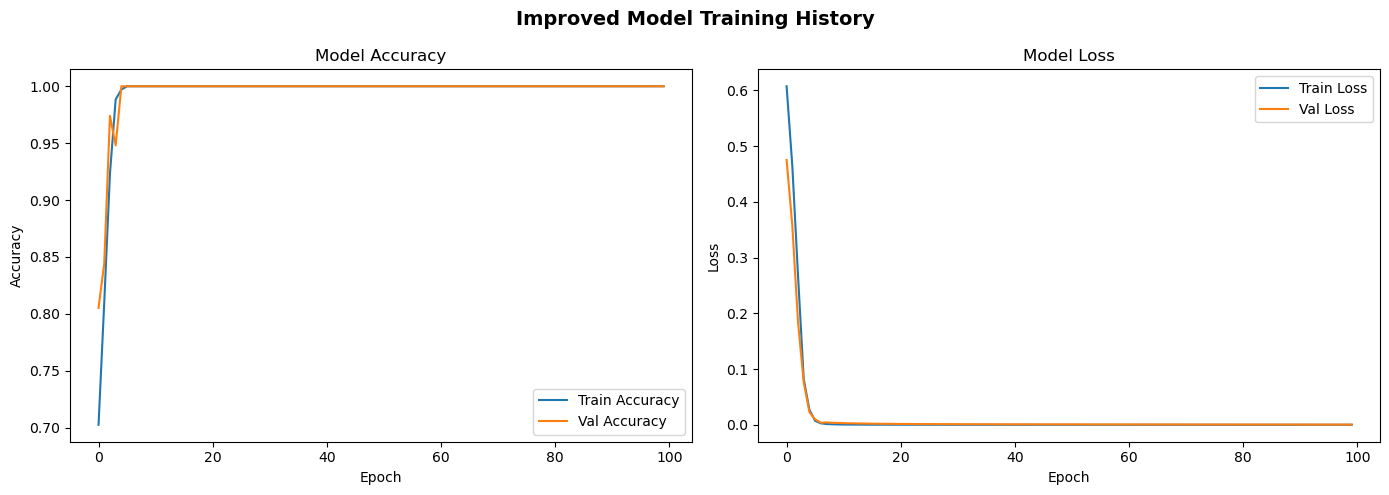

In [7]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
axes[0].plot(history_v2.history["accuracy"],     label="Train Accuracy")
axes[0].plot(history_v2.history["val_accuracy"], label="Val Accuracy")
axes[0].set_title("Model Accuracy")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()

# Loss
axes[1].plot(history_v2.history["loss"],     label="Train Loss")
axes[1].plot(history_v2.history["val_loss"], label="Val Loss")
axes[1].set_title("Model Loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()

plt.suptitle("Improved Model Training History", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

**Which approach(es) did you find helpful to improve your model performance?**

In [9]:
# Epochs + deeper architecture together is the winning combination here.
# The dataset is small enough that training is fast, so there's little cost to running more epochs.
# If you're still not hitting >0.95 accuracy, the next step would be adding Dropout layers to reduce overfitting, which goes beyond this challenge but is worth knowing about.